In [1]:
# 모듈 및 데이터 로드
from sklearn.datasets import load_breast_cancer
from sklearn.linear_model import LogisticRegression

data = load_breast_cancer()

# x, y 데이터 생성
X = data.data

# 악성을 1, 양성을 0으로
y = 1 - data.target

# 특징으로 사용할 데이터를 평균으로 구분하는 10개 열로 축소
X = X[:, :10]

# 로지스틱 회귀 모델 생성
model_lor = LogisticRegression(solver = 'lbfgs')
model_lor.fit(X,y)
y_pred = model_lor.predict(X)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


**오차 행렬(혼동 행렬) 생성**

In [2]:
# 종속 변수와 예측 결과로 혼동 행렬 생성
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y, y_pred)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[337  20]
 [ 30 182]]


**정확도의 개념을 설명하고, 정확도를 구해 해당 값을 통해 알 수 있는 점을 쓰시오.**

정확도는 전체 예측 건수 중에서 모델이 실제값과 일치하게 예측한 건수가 어느 정도인지를 나타내는 지표이다.

In [3]:
from sklearn.metrics import accuracy_score

acc = accuracy_score(y, y_pred)

print(f"모델의 정확도: {acc:.4f}")

모델의 정확도: 0.9121


위 수치를 보았을 때 모델의 정확도가 91.21%이므로 모델이 암을 꽤 잘 구분한다는 것을 의미한다. 또한 앞의 10개 열만 사용했음에도 높은 정확도가 나왔으므로 이는 10개의 특징들이 암을 진단하는 데 매우 중요한 변수임을 알 수 있다.

**정밀도의 개념을 설명하고, 정확도를 구해 해당 값을 통해 알 수 있는 점을 쓰시오.**

정밀도는 Positive 예측값 중에서 실제로 정말 Positive였던 비율을 의미한다.

In [4]:
from sklearn.metrics import precision_score

precision = precision_score(y, y_pred)

print(f"모델의 정밀도: {precision:.4f}")

모델의 정밀도: 0.9010


위 수치를 보았을 때 정밀도가 90.1%이므로 모델의 확신에 대한 신뢰도가 상당히 높다는 것을 알 수 있다. 정상인 사람을 암이라고 잘못 판단하여 검사나 정밀 진단을 받게 할 확률은 약 9.9%로 낮다. 따라서 이는 환자에게 불필요한 비용을 초래하는 경우가 적다는 것을 알 수 있다. 또한 정확도와 정밀도가 비슷하게 높은 수준인 걸로 보아 꽤 균형잡힌 판단이 이루어지고 있음을 알 수 있다.

**재현율의 개념을 설명하고, 정확도를 구해 해당 값을 통해 알 수 있는 점을 쓰시오.**

재현율은 실제 Positive 중에서 모델이 얼마나 poitive를 잘 찾아냈는지에 대한 비율을 의미한다.

In [5]:
from sklearn.metrics import recall_score

recall = recall_score(y, y_pred)

print(f"모델의 재현율: {recall:.4f}")

모델의 재현율: 0.8585


재현율은 85.9%로 정확도나 정밀도에 비해 낮게 보이며 이 모델이 확실하지 않을 경우 암이라고 진단하지 않는 다는 것을 알 수 있다.

**F1 score의 개념을 설명하고, 정확도를 구해 해당 값을 통해 알 수 있는 점을 쓰시오.**

F1 Score는 정밀도와 재현율의 조화 평균 값으로 두 지표 중 어느 한쪽으로 치우치지 않고 균형을 이룰 때 높은 값을 가진다.

In [6]:
from sklearn.metrics import f1_score

f1 = f1_score(y, y_pred)

print(f"모델의 F1 Score: {f1:.4f}")

모델의 F1 Score: 0.8792


F1 Score가 정확도보다 낮게 나온 것으로 보아 이는 모델이 단순히 정확도에 비해 실제 환자를 놓치지 않으면서 오진도 피하는 종합적인 분류 능력은 떨어진다는 것을 알 수 있다.

**예측 확률(pred_proba) : 0으로 예측할 확률이 0.1보다 크면 y_pred2 에 넣는다 가정.**

In [8]:
pred_proba = model_lor.predict_proba(X)

from sklearn.preprocessing import Binarizer

binarizer = binarizer_test = Binarizer(threshold=0.1)
pred_proba_1 = pred_proba[:, 1].reshape(-1, 1)
y_pred2 = binarizer_test.fit_transform(pred_proba_1)

print(y_pred2[:5])

[[1.]
 [1.]
 [1.]
 [1.]
 [1.]]


In [9]:
# y과 y_pred2의 혼동행렬, 정확도, 정밀도, 재현율, f1 score 구하기
# 1. 혼동 행렬 (Confusion Matrix)
cm2 = confusion_matrix(y, y_pred2)

# 2. 각 평가지표 계산
acc2 = accuracy_score(y, y_pred2)
prec2 = precision_score(y, y_pred2)
rec2 = recall_score(y, y_pred2)
f1_2 = f1_score(y, y_pred2)

# 결과 출력
print("--- [y_pred2] 평가 결과 ---")
print(f"혼동 행렬:\n{cm2}")
print(f"정확도: {acc2:.4f}")
print(f"정밀도: {prec2:.4f}")
print(f"재현율: {rec2:.4f}")
print(f"F1 Score: {f1_2:.4f}")

--- [y_pred2] 평가 결과 ---
혼동 행렬:
[[267  90]
 [  6 206]]
정확도: 0.8313
정밀도: 0.6959
재현율: 0.9717
F1 Score: 0.8110


**ROC 곡선 시각화**

In [10]:
from sklearn.metrics import roc_curve


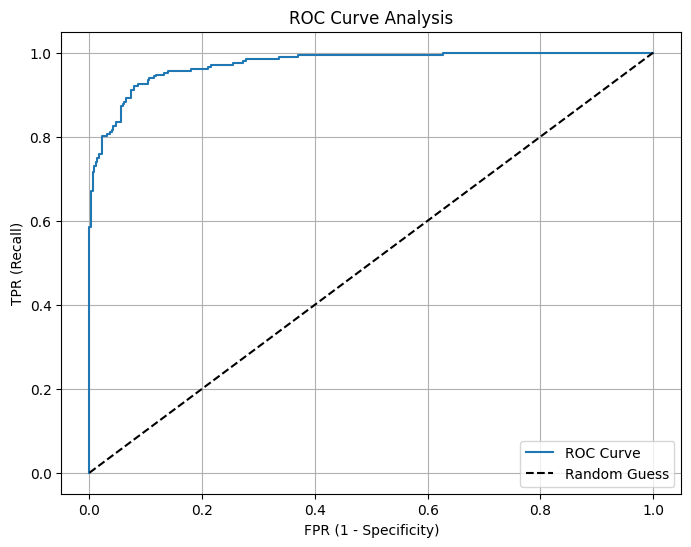

In [12]:
import matplotlib.pyplot as plt

pred_proba_1 = model_lor.predict_proba(X)[:, 1]

fpr, tpr, thresholds = roc_curve(y, pred_proba_1)

plt.figure(figsize=(8, 6))

plt.plot(fpr, tpr, label='ROC Curve')
plt.plot([0, 1], [0, 1], 'k--', label='Random Guess')

plt.xlabel('FPR (1 - Specificity)')
plt.ylabel('TPR (Recall)')
plt.title('ROC Curve Analysis')
plt.legend()
plt.grid(True)
plt.show()

**ROC AUC 값을 구하고 해당 값을 통해 알 수 있는 점을 쓰시오.**

In [13]:
from sklearn.metrics import roc_auc_score

auc_value = roc_auc_score(y, model_lor.predict_proba(X)[:, 1])

print(f"ROC AUC 값: {auc_value:.4f}")

ROC AUC 값: 0.9741


AUC는 모델이 무작위로 뽑은 '악성'데이터와 '양성'데이터의 순서를 올바르게 나열할 확률과 같으므로 0.9741의 높은 수치로 인해 모델이 두 클래스를 변별하는 능력이 매우 높음을 알 수 있다.